# K-Moda MMM — Fase 4: Modelos Clásicos

**Objetivo:** Ajustar modelos lineales regularizados (Ridge, Lasso, ElasticNet) sobre las features adstock de la Fase 3. Obtener coeficientes de atribución y ROAS por canal.

**Input:** `data/df_model.parquet`

**Outputs:**
- `data/df_coefs.parquet` — coeficientes y ROAS por canal y modelo
- `data/df_predicciones.parquet` — Y_pred train y test

---
**Estructura:**
1. Análisis de distribución 2024 vs train (KS test + Chow) — ¿es el test representativo?
2. Preparación de matrices X/y con StandardScaler
3. Cross-validación temporal (TimeSeriesSplit)
4. Ajuste Ridge, Lasso, ElasticNet con GridSearchCV
5. Evaluación en test: MAPE, RMSE, R²
6. Coeficientes e interpretación
7. ROAS por canal

## 0. Configuración e Imports

In [23]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline

ROOT     = Path('.')
DATA_OUT = ROOT / 'data'
IMG_DIR  = ROOT / 'img'
IMG_DIR.mkdir(exist_ok=True)

KM = {
    'gold': '#C9A84C', 'gold_light': '#E8D5A3', 'charcoal': '#2C2C2C',
    'warm_gray': '#6B6560', 'off_white': '#F7F5F0', 'white': '#FFFFFF',
    'paid_search': '#1A6B8A', 'social_paid': '#E07B39', 'video': '#8B5E9E',
    'display': '#3A9E6F', 'email_crm': '#D4A843', 'radio': '#C0504D',
    'exterior': '#4F7CAC', 'prensa': '#7A7A52',
    'positive': '#2E7D52', 'neutral': '#C9A84C', 'negative': '#B33A3A',
    'ridge': '#1A6B8A', 'lasso': '#E07B39', 'elasticnet': '#8B5E9E',
}
CANAL_COLOR = {
    'Paid Search': KM['paid_search'], 'Social Paid': KM['social_paid'],
    'Video Online': KM['video'],      'Display':     KM['display'],
    'Email CRM':   KM['email_crm'],   'Radio Local': KM['radio'],
    'Exterior':    KM['exterior'],    'Prensa':      KM['prensa'],
}
plt.rcParams.update({
    'figure.facecolor': KM['off_white'], 'axes.facecolor': KM['off_white'],
    'axes.edgecolor': KM['warm_gray'],   'axes.labelcolor': KM['charcoal'],
    'xtick.color': KM['charcoal'],       'ytick.color': KM['charcoal'],
    'text.color': KM['charcoal'],        'grid.color': KM['gold_light'],
    'grid.alpha': 0.5, 'axes.grid': True, 'font.family': 'sans-serif',
    'font.size': 11,
})

def save_fig(name, fig=None):
    f = fig or plt.gcf()
    p = IMG_DIR / f'{name}.png'
    f.savefig(p, dpi=150, bbox_inches='tight', facecolor=f.get_facecolor())
    print(f'  Guardado: {p}')

print('Config cargada.')

Config cargada.


## 1. Carga y partición

In [24]:
df = pd.read_parquet(DATA_OUT / 'df_model.parquet')

ADSTOCK_COLS = [c for c in df.columns if c.startswith('adstock_')]
FLAGS_EXOG   = [c for c in df.columns if c.endswith('_flag')]
CONT_EXOG_Z  = [c for c in df.columns if c.endswith('_z')]
FEATURE_COLS = ADSTOCK_COLS + FLAGS_EXOG + CONT_EXOG_Z
TARGET       = 'venta_neta_sin_iva_eur'

TRAIN_END  = pd.Timestamp('2023-12-31')
TEST_START = pd.Timestamp('2024-01-01')

df_train = df[df['semana_inicio'] <= TRAIN_END].copy()
df_test  = df[df['semana_inicio'] >= TEST_START].copy()

X_train = df_train[FEATURE_COLS].values
y_train = df_train[TARGET].values
X_test  = df_test[FEATURE_COLS].values
y_test  = df_test[TARGET].values

print(f'TRAIN: {X_train.shape}  |  TEST: {X_test.shape}')
print(f'Features: {FEATURE_COLS}')
print(f'\nY_train — media: {y_train.mean():,.0f} EUR  std: {y_train.std():,.0f} EUR  CV: {y_train.std()/y_train.mean()*100:.1f}%')
print(f'Y_test  — media: {y_test.mean():,.0f} EUR  std: {y_test.std():,.0f} EUR  CV: {y_test.std()/y_test.mean()*100:.1f}%')

TRAIN: (209, 15)  |  TEST: (53, 15)
Features: ['adstock_display', 'adstock_email_crm', 'adstock_exterior', 'adstock_paid_search', 'adstock_prensa', 'adstock_radio_local', 'adstock_social_paid', 'adstock_video_online', 'black_friday_flag', 'navidad_flag', 'rebajas_flag', 'semana_santa_flag', 'incidencia_ecommerce_flag', 'temperatura_media_c_z', 'turismo_indice_z']

Y_train — media: 2,719,817 EUR  std: 617,963 EUR  CV: 22.7%
Y_test  — media: 3,766,953 EUR  std: 371,335 EUR  CV: 9.9%


## 2. Análisis de distribución: Test 2024 vs Train 2020-2023

Antes de evaluar el modelo en test, verificamos si 2024 tiene una distribución de ventas estadísticamente distinta al periodo de entrenamiento. Un cambio estructural invalidaría las métricas de test como indicadores de generalización.

In [25]:
# --- Estadísticas descriptivas ---
print('COMPARATIVA DISTRIBUCIÓN TRAIN vs TEST')
print('=' * 55)
stats_comp = pd.DataFrame({
    'TRAIN (2020-2023)': {
        'n': len(y_train),
        'Media (M€)':  y_train.mean() / 1e6,
        'Mediana (M€)': np.median(y_train) / 1e6,
        'Std (M€)':    y_train.std() / 1e6,
        'CV (%)':      y_train.std() / y_train.mean() * 100,
        'Min (M€)':    y_train.min() / 1e6,
        'Max (M€)':    y_train.max() / 1e6,
    },
    'TEST (2024)': {
        'n': len(y_test),
        'Media (M€)':  y_test.mean() / 1e6,
        'Mediana (M€)': np.median(y_test) / 1e6,
        'Std (M€)':    y_test.std() / 1e6,
        'CV (%)':      y_test.std() / y_test.mean() * 100,
        'Min (M€)':    y_test.min() / 1e6,
        'Max (M€)':    y_test.max() / 1e6,
    }
})
print(stats_comp.round(3).to_string())

# --- KS test ---
ks_stat, ks_pval = stats.ks_2samp(y_train, y_test)
print(f'\nKS test (Kolmogorov-Smirnov):')
print(f'  Estadístico KS: {ks_stat:.4f}')
print(f'  p-valor:        {ks_pval:.4f}')
if ks_pval < 0.05:
    print('  CONCLUSION: distribuciones DISTINTAS (p < 0.05) — 2024 tiene estructura diferente al train')
    print('  Implicacion: las metricas de test miden capacidad predictiva en condiciones cambiantes.')
else:
    print('  CONCLUSION: distribuciones NO distinguibles (p >= 0.05) — test es representativo del train')

# --- Test de Chow (cambio estructural) ---
# Aproximación: t-test de medias + F-test de varianzas
t_stat, t_pval = stats.ttest_ind(y_train, y_test, equal_var=False)
f_stat = y_test.var() / y_train.var()
f_pval = 1 - stats.f.cdf(f_stat, len(y_test)-1, len(y_train)-1)
print(f'\nTest de medias (Welch t-test):')
print(f'  t={t_stat:.3f}  p={t_pval:.4f}  → media 2024 {"DISTINTA" if t_pval < 0.05 else "similar"} a train')
print(f'Test de varianzas (F-test):')
print(f'  F={f_stat:.3f}  p={f_pval:.4f}  → varianza 2024 {"DISTINTA" if f_pval < 0.05 else "similar"} a train')

COMPARATIVA DISTRIBUCIÓN TRAIN vs TEST
              TRAIN (2020-2023)  TEST (2024)
n                       209.000       53.000
Media (M€)                2.720        3.767
Mediana (M€)              2.791        3.816
Std (M€)                  0.618        0.371
CV (%)                   22.721        9.858
Min (M€)                  1.290        1.093
Max (M€)                  3.442        3.859

KS test (Kolmogorov-Smirnov):
  Estadístico KS: 0.9811
  p-valor:        0.0000
  CONCLUSION: distribuciones DISTINTAS (p < 0.05) — 2024 tiene estructura diferente al train
  Implicacion: las metricas de test miden capacidad predictiva en condiciones cambiantes.

Test de medias (Welch t-test):
  t=-15.631  p=0.0000  → media 2024 DISTINTA a train
Test de varianzas (F-test):
  F=0.361  p=1.0000  → varianza 2024 similar a train


  Guardado: img\04a_distribucion_train_test.png


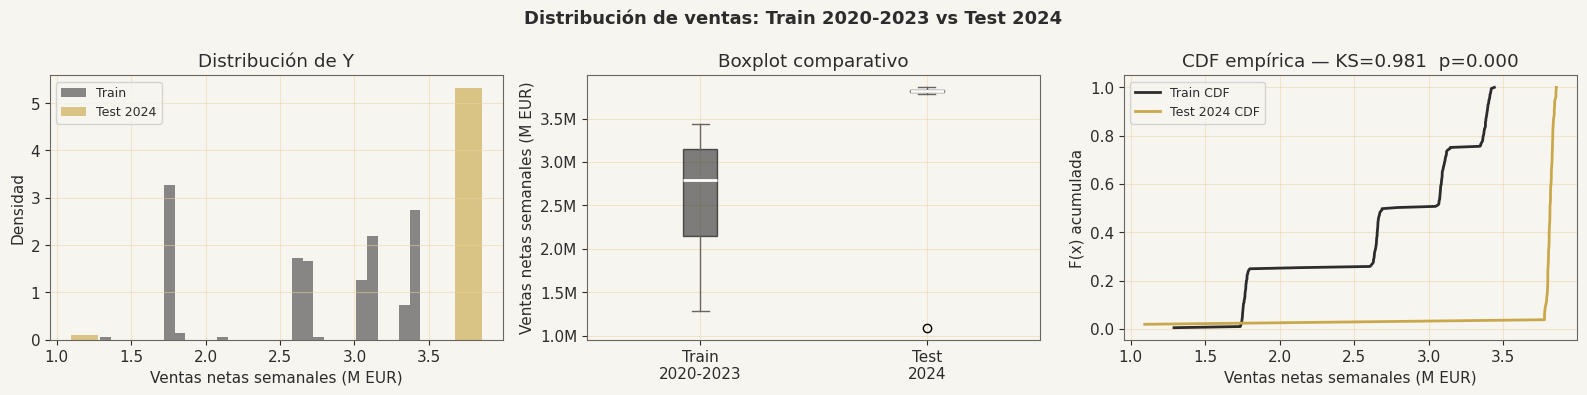

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Distribución de ventas: Train 2020-2023 vs Test 2024',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

# Histogramas superpuestos
ax = axes[0]
ax.hist(y_train/1e6, bins=30, color=KM['charcoal'], alpha=0.55, label='Train', density=True)
ax.hist(y_test/1e6,  bins=15, color=KM['gold'],     alpha=0.65, label='Test 2024', density=True)
ax.set_xlabel('Ventas netas semanales (M EUR)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de Y')
ax.legend(fontsize=9)

# Boxplot comparativo
ax2 = axes[1]
bp = ax2.boxplot([y_train/1e6, y_test/1e6], patch_artist=True,
                 medianprops=dict(color='white', lw=2),
                 whiskerprops=dict(color=KM['warm_gray']),
                 capprops=dict(color=KM['warm_gray']))
bp['boxes'][0].set_facecolor(KM['charcoal']); bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor(KM['gold']);     bp['boxes'][1].set_alpha(0.8)
ax2.set_xticklabels(['Train\n2020-2023', 'Test\n2024'])
ax2.set_ylabel('Ventas netas semanales (M EUR)')
ax2.set_title('Boxplot comparativo')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}M'))

# CDF empírica (KS visual)
ax3 = axes[2]
train_sorted = np.sort(y_train/1e6)
test_sorted  = np.sort(y_test/1e6)
ax3.plot(train_sorted, np.arange(1, len(train_sorted)+1)/len(train_sorted),
         color=KM['charcoal'], lw=2, label='Train CDF')
ax3.plot(test_sorted,  np.arange(1, len(test_sorted)+1)/len(test_sorted),
         color=KM['gold'], lw=2, label='Test 2024 CDF')
ax3.set_xlabel('Ventas netas semanales (M EUR)')
ax3.set_ylabel('F(x) acumulada')
ax3.set_title(f'CDF empírica — KS={ks_stat:.3f}  p={ks_pval:.3f}')
ax3.legend(fontsize=9)

plt.tight_layout()
save_fig('04a_distribucion_train_test')
plt.show()

## 3. Preparación de matrices y pipeline de escala

In [27]:
# Añadir tendencia temporal directamente a df, df_train y df_test
t0 = df['semana_inicio'].min()
df['tendencia']       = (df['semana_inicio']       - t0).dt.days / 365.25
df_train['tendencia'] = (df_train['semana_inicio'] - t0).dt.days / 365.25
df_test['tendencia']  = (df_test['semana_inicio']  - t0).dt.days / 365.25

FEATURE_COLS_TREND = FEATURE_COLS + ['tendencia']

X_train_t = df_train[FEATURE_COLS_TREND].values
X_test_t  = df_test[FEATURE_COLS_TREND].values

# StandardScaler ajustado SOLO sobre train
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_t)
X_test_sc  = scaler.transform(X_test_t)

print(f'Features (con tendencia): {len(FEATURE_COLS_TREND)}')
print(f'X_train_sc shape: {X_train_sc.shape}  |  media por col (debe ser ~0): OK')

# TimeSeriesSplit — respeta el orden temporal, sin shuffle
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

print(f'\nTimeSeriesSplit (n_splits={N_SPLITS}):')
for i, (tr_idx, val_idx) in enumerate(tscv.split(X_train_sc)):
    tr_dates  = df_train.iloc[tr_idx]['semana_inicio']
    val_dates = df_train.iloc[val_idx]['semana_inicio']
    print(f'  Fold {i+1}: TRAIN {tr_dates.min().date()}→{tr_dates.max().date()} ({len(tr_idx)} sem)  '
          f'VAL {val_dates.min().date()}→{val_dates.max().date()} ({len(val_idx)} sem)')

Features (con tendencia): 16
X_train_sc shape: (209, 16)  |  media por col (debe ser ~0): OK

TimeSeriesSplit (n_splits=5):
  Fold 1: TRAIN 2019-12-30→2020-09-21 (39 sem)  VAL 2020-09-28→2021-05-17 (34 sem)
  Fold 2: TRAIN 2019-12-30→2021-05-17 (73 sem)  VAL 2021-05-24→2022-01-10 (34 sem)
  Fold 3: TRAIN 2019-12-30→2022-01-10 (107 sem)  VAL 2022-01-17→2022-09-05 (34 sem)
  Fold 4: TRAIN 2019-12-30→2022-09-05 (141 sem)  VAL 2022-09-12→2023-05-01 (34 sem)
  Fold 5: TRAIN 2019-12-30→2023-05-01 (175 sem)  VAL 2023-05-08→2023-12-25 (34 sem)


## 4. GridSearchCV — Ridge, Lasso, ElasticNet

In [28]:
# Grids de hiperparámetros
ALPHAS = np.logspace(-3, 4, 50)  # 0.001 → 10000

modelos_config = {
    'Ridge': {
        'model': Ridge(max_iter=10000),
        'grid':  {'alpha': ALPHAS},
    },
    'Lasso': {
        'model': Lasso(max_iter=10000),
        'grid':  {'alpha': ALPHAS},
    },
    'ElasticNet': {
        'model': ElasticNet(max_iter=10000),
        'grid':  {'alpha': ALPHAS,
                  'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
    },
}

resultados = {}

for nombre, cfg in modelos_config.items():
    gs = GridSearchCV(
        cfg['model'], cfg['grid'],
        cv=tscv, scoring='neg_mean_absolute_percentage_error',
        n_jobs=-1, refit=True
    )
    gs.fit(X_train_sc, y_train)

    # Predicciones
    y_pred_train = gs.predict(X_train_sc)
    y_pred_test  = gs.predict(X_test_sc)

    # Métricas
    mape_train = mean_absolute_percentage_error(y_train, y_pred_train) * 100
    mape_test  = mean_absolute_percentage_error(y_test,  y_pred_test)  * 100
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train)) / 1e6
    rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))  / 1e6
    r2_train   = r2_score(y_train, y_pred_train)
    r2_test    = r2_score(y_test,  y_pred_test)

    resultados[nombre] = {
        'gs': gs,
        'best_params':   gs.best_params_,
        'coefs':         gs.best_estimator_.coef_,
        'intercept':     gs.best_estimator_.intercept_,
        'y_pred_train':  y_pred_train,
        'y_pred_test':   y_pred_test,
        'mape_train': mape_train, 'mape_test': mape_test,
        'rmse_train': rmse_train, 'rmse_test': rmse_test,
        'r2_train':   r2_train,   'r2_test':   r2_test,
    }

    print(f'{nombre:12s}  params={gs.best_params_}')
    print(f'             TRAIN → MAPE={mape_train:.1f}%  RMSE={rmse_train:.3f}M  R²={r2_train:.4f}')
    print(f'             TEST  → MAPE={mape_test:.1f}%  RMSE={rmse_test:.3f}M  R²={r2_test:.4f}')
    print()

Ridge         params={'alpha': np.float64(2.6826957952797246)}
             TRAIN → MAPE=5.4%  RMSE=0.162M  R²=0.9314
             TEST  → MAPE=8.2%  RMSE=0.441M  R²=-0.4131

Lasso         params={'alpha': np.float64(10000.0)}
             TRAIN → MAPE=5.7%  RMSE=0.167M  R²=0.9273
             TEST  → MAPE=8.1%  RMSE=0.444M  R²=-0.4277

ElasticNet    params={'alpha': np.float64(0.2682695795279725), 'l1_ratio': 0.9}
             TRAIN → MAPE=5.5%  RMSE=0.163M  R²=0.9303
             TEST  → MAPE=8.0%  RMSE=0.437M  R²=-0.3855



## 5. Comparativa de métricas y selección de modelo

In [29]:
# Tabla resumen
rows = []
for nombre, r in resultados.items():
    rows.append({
        'Modelo': nombre,
        'MAPE train (%)': round(r['mape_train'], 2),
        'MAPE test (%)':  round(r['mape_test'],  2),
        'RMSE train (M€)': round(r['rmse_train'], 3),
        'RMSE test (M€)':  round(r['rmse_test'],  3),
        'R² train': round(r['r2_train'], 4),
        'R² test':  round(r['r2_test'],  4),
        'Overfit (ΔMAPE)': round(r['mape_test'] - r['mape_train'], 2),
    })
df_metrics = pd.DataFrame(rows).set_index('Modelo')
print('COMPARATIVA DE MODELOS')
print('=' * 70)
print(df_metrics.to_string())

# Seleccionar mejor modelo por MAPE test
mejor_nombre = df_metrics['MAPE test (%)'].idxmin()
mejor = resultados[mejor_nombre]
print(f'\nMejor modelo (menor MAPE test): {mejor_nombre}')
print(f'  MAPE test = {mejor["mape_test"]:.1f}%  |  R² test = {mejor["r2_test"]:.4f}')

COMPARATIVA DE MODELOS
            MAPE train (%)  MAPE test (%)  RMSE train (M€)  RMSE test (M€)  R² train  R² test  Overfit (ΔMAPE)
Modelo                                                                                                        
Ridge                 5.42           8.16            0.162           0.441    0.9314  -0.4131             2.74
Lasso                 5.68           8.10            0.167           0.444    0.9273  -0.4277             2.42
ElasticNet            5.53           7.95            0.163           0.437    0.9303  -0.3855             2.42

Mejor modelo (menor MAPE test): ElasticNet
  MAPE test = 8.0%  |  R² test = -0.3855


  Guardado: img\04b_comparativa_metricas.png


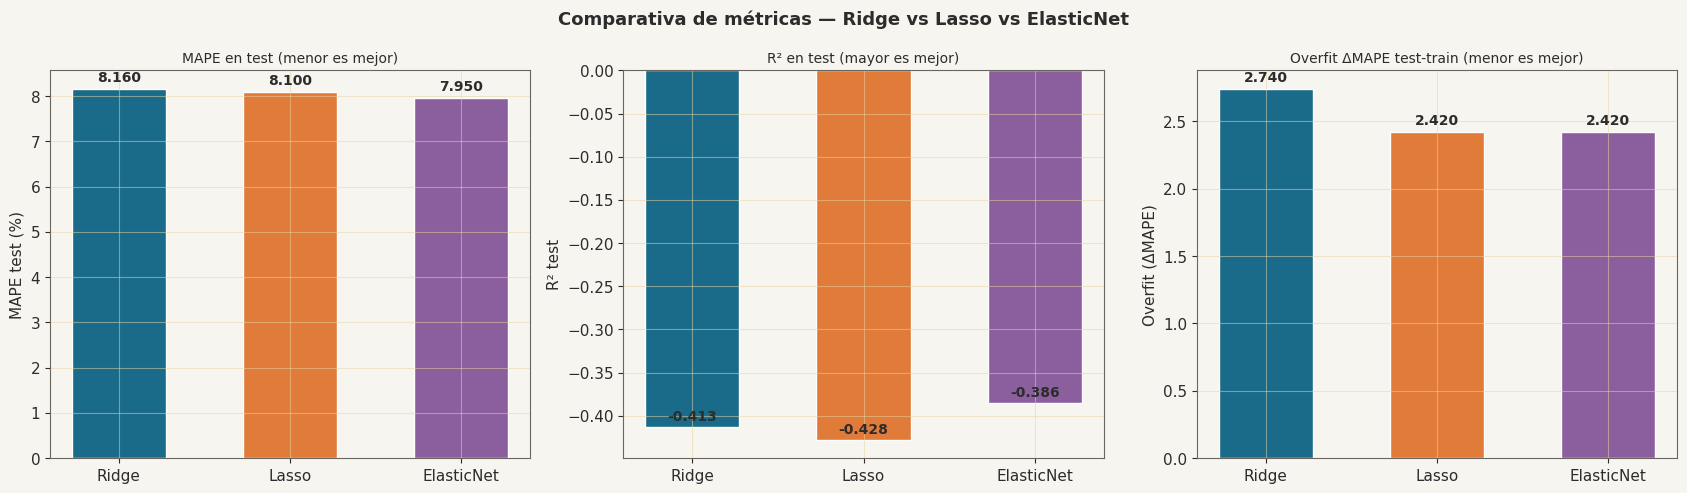

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Comparativa de métricas — Ridge vs Lasso vs ElasticNet',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

metricas = [
    ('MAPE test (%)',  'MAPE en test (menor es mejor)',  'lower'),
    ('R² test',        'R² en test (mayor es mejor)',    'higher'),
    ('Overfit (ΔMAPE)', 'Overfit ΔMAPE test-train (menor es mejor)', 'lower'),
]
model_colors = {'Ridge': KM['ridge'], 'Lasso': KM['lasso'], 'ElasticNet': KM['elasticnet']}

for ax, (metrica, titulo, mejor_dir) in zip(axes, metricas):
    vals = df_metrics[metrica]
    bars = ax.bar(vals.index, vals.values,
                  color=[model_colors[m] for m in vals.index],
                  edgecolor='white', width=0.55)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + abs(vals.values.max()) * 0.02,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(titulo, fontsize=10)
    ax.set_ylabel(metrica)

plt.tight_layout()
save_fig('04b_comparativa_metricas')
plt.show()

## 6. Ajuste visual: Predicción vs Realidad

  Guardado: img\04c_pred_vs_real.png


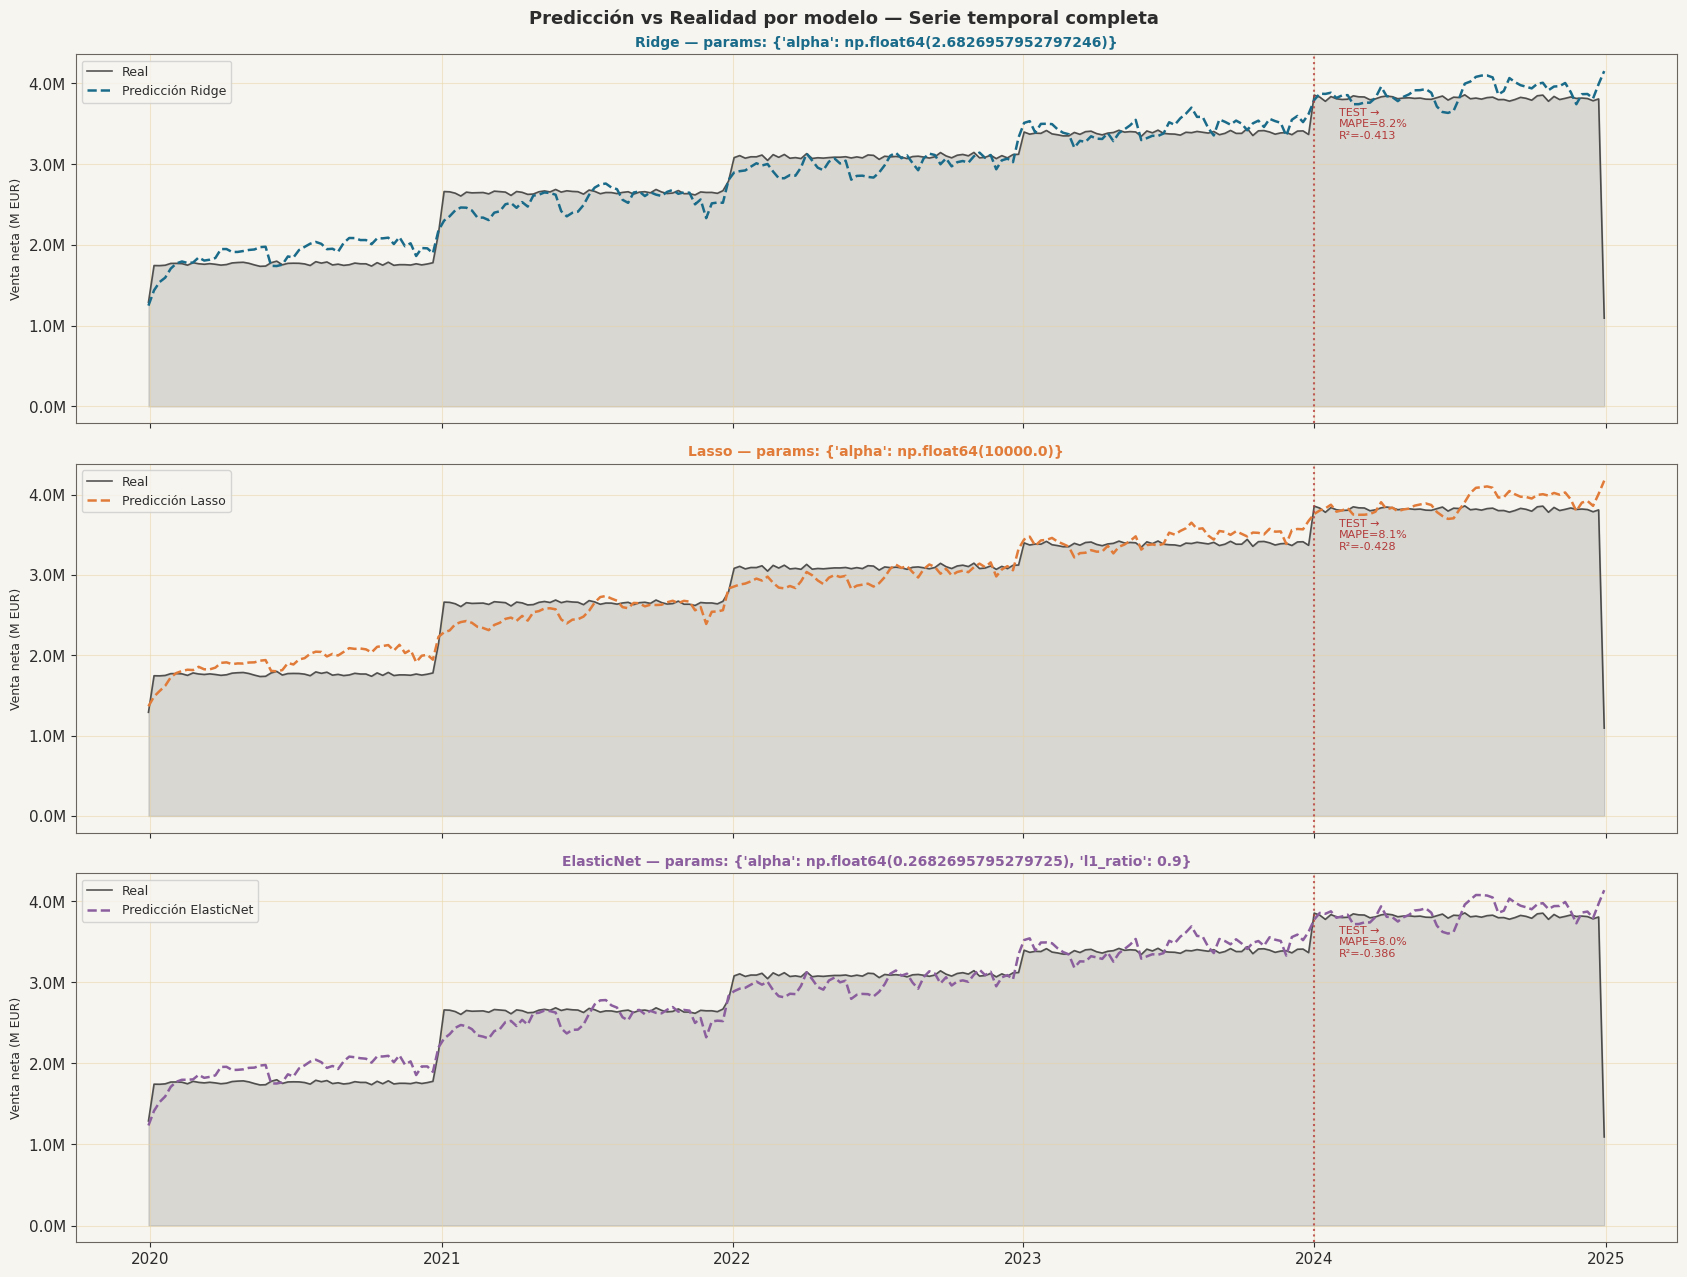

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(17, 13), sharex=True)
fig.suptitle('Predicción vs Realidad por modelo — Serie temporal completa',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

fechas_all = pd.concat([df_train['semana_inicio'], df_test['semana_inicio']]).values
y_all = np.concatenate([y_train, y_test])

for ax, (nombre, r) in zip(axes, resultados.items()):
    y_pred_all = np.concatenate([r['y_pred_train'], r['y_pred_test']])
    color = model_colors[nombre]

    # Real
    ax.fill_between(fechas_all, y_all/1e6, alpha=0.15, color=KM['charcoal'])
    ax.plot(fechas_all, y_all/1e6, color=KM['charcoal'], lw=1.2, label='Real', alpha=0.8)
    # Predicción
    ax.plot(fechas_all, y_pred_all/1e6, color=color, lw=1.8, ls='--', label=f'Predicción {nombre}')
    # Separador train/test
    ax.axvline(pd.Timestamp('2024-01-01'), color=KM['negative'], lw=1.5, ls=':', alpha=0.8)
    ax.text(pd.Timestamp('2024-02-01'), (y_all/1e6).max() * 0.96,
            f'TEST →\nMAPE={r["mape_test"]:.1f}%\nR²={r["r2_test"]:.3f}',
            fontsize=8, color=KM['negative'], va='top')
    ax.set_ylabel('Venta neta (M EUR)', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}M'))
    ax.legend(fontsize=9, loc='upper left')
    ax.set_title(f'{nombre} — params: {r["best_params"]}', fontsize=10,
                 color=color, fontweight='bold')

plt.tight_layout()
save_fig('04c_pred_vs_real')
plt.show()

## 7. Análisis de residuos (mejor modelo)

Shapiro-Wilk (normalidad residuos train): W=0.9871  p=0.0551
  → residuos compatibles con normalidad (p >= 0.05)
  Guardado: img\04d_residuos.png


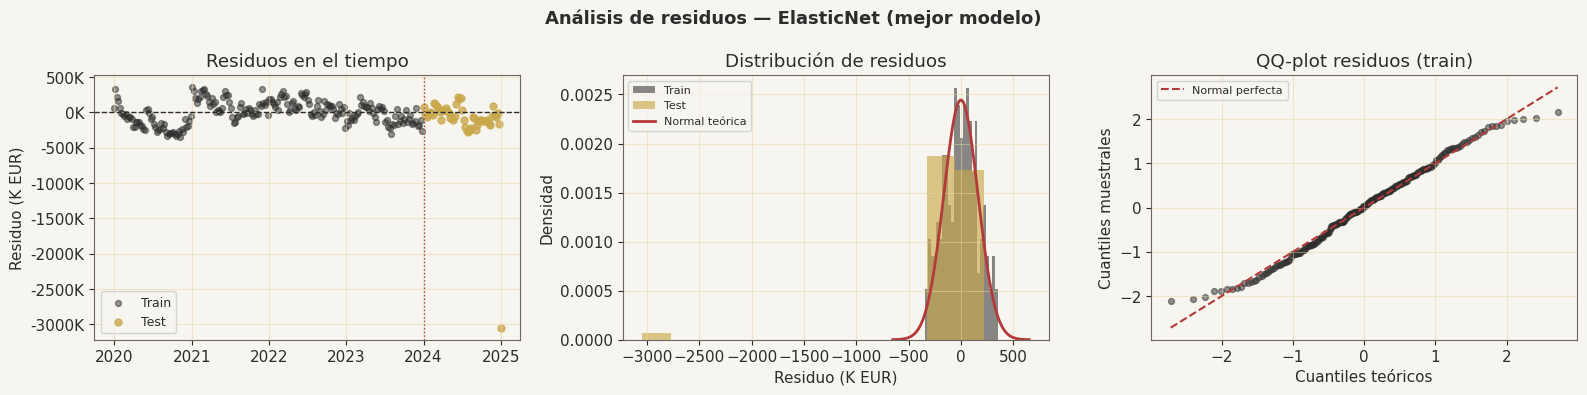

In [32]:
r = resultados[mejor_nombre]
residuos_train = y_train - r['y_pred_train']
residuos_test  = y_test  - r['y_pred_test']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f'Análisis de residuos — {mejor_nombre} (mejor modelo)',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

# Residuos vs tiempo
ax = axes[0]
ax.scatter(df_train['semana_inicio'], residuos_train/1e3,
           color=KM['charcoal'], alpha=0.5, s=18, label='Train')
ax.scatter(df_test['semana_inicio'], residuos_test/1e3,
           color=KM['gold'], alpha=0.8, s=25, label='Test')
ax.axhline(0, color=KM['charcoal'], lw=1, ls='--')
ax.axvline(pd.Timestamp('2024-01-01'), color=KM['negative'], lw=1, ls=':')
ax.set_ylabel('Residuo (K EUR)')
ax.set_title('Residuos en el tiempo')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}K'))

# Histograma de residuos
ax2 = axes[1]
ax2.hist(residuos_train/1e3, bins=25, color=KM['charcoal'], alpha=0.55,
         label='Train', density=True)
ax2.hist(residuos_test/1e3,  bins=12, color=KM['gold'],     alpha=0.65,
         label='Test', density=True)
# Curva normal sobre train
mu, sigma = residuos_train.mean()/1e3, residuos_train.std()/1e3
x_norm = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
ax2.plot(x_norm, stats.norm.pdf(x_norm, mu, sigma),
         color=KM['negative'], lw=2, label='Normal teórica')
ax2.set_xlabel('Residuo (K EUR)')
ax2.set_ylabel('Densidad')
ax2.set_title('Distribución de residuos')
ax2.legend(fontsize=8)

# QQ plot
ax3 = axes[2]
res_std = (residuos_train - residuos_train.mean()) / residuos_train.std()
qq = stats.probplot(res_std, dist='norm')
ax3.scatter(qq[0][0], qq[0][1], color=KM['charcoal'], alpha=0.5, s=18)
xline = np.linspace(qq[0][0].min(), qq[0][0].max(), 100)
ax3.plot(xline, xline, color=KM['negative'], lw=1.5, ls='--', label='Normal perfecta')
ax3.set_xlabel('Cuantiles teóricos')
ax3.set_ylabel('Cuantiles muestrales')
ax3.set_title('QQ-plot residuos (train)')
ax3.legend(fontsize=8)

# Shapiro-Wilk
sw_stat, sw_pval = stats.shapiro(residuos_train)
print(f'Shapiro-Wilk (normalidad residuos train): W={sw_stat:.4f}  p={sw_pval:.4f}')
print(f'  → residuos {"NO normales" if sw_pval < 0.05 else "compatibles con normalidad"} (p {"<" if sw_pval < 0.05 else ">="} 0.05)')

plt.tight_layout()
save_fig('04d_residuos')
plt.show()

## 8. Coeficientes del modelo — Interpretación

  Guardado: img\04e_coeficientes.png


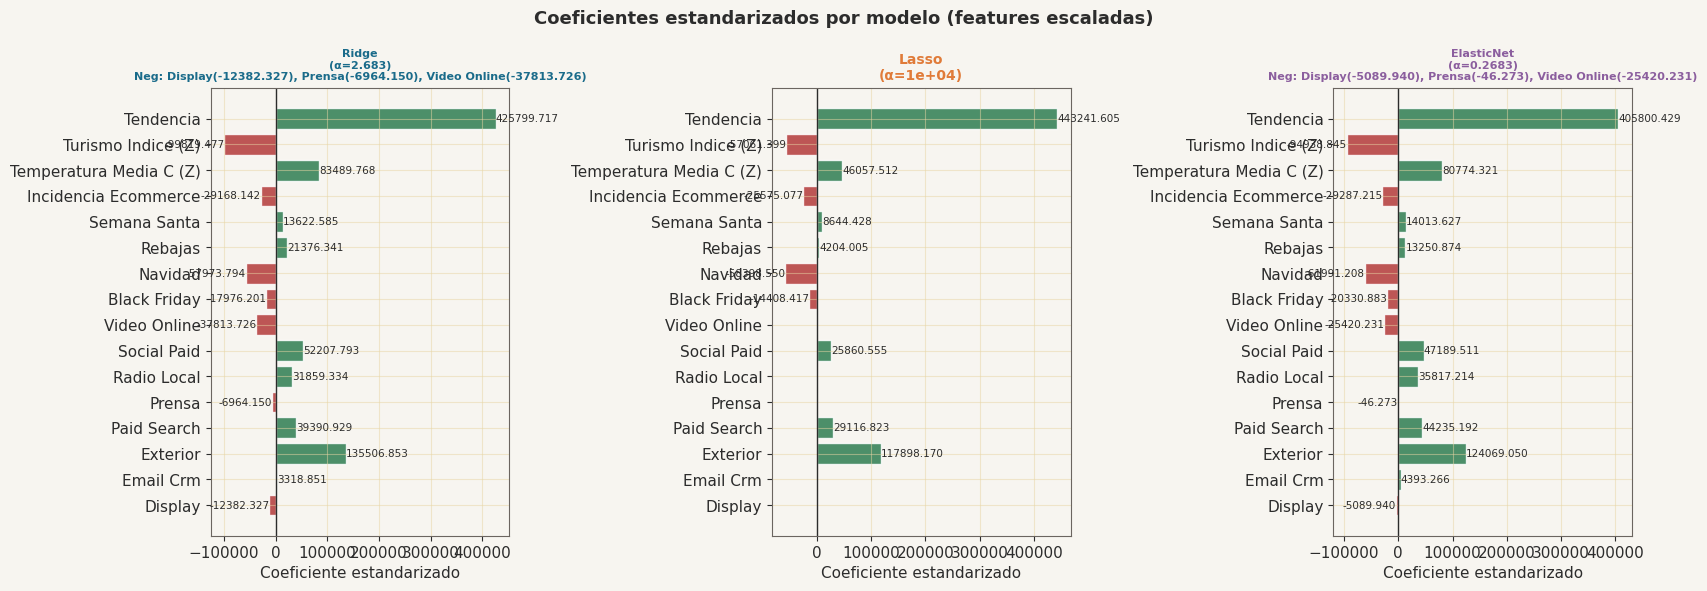

CANALES CON COEFICIENTE NEGATIVO (limitación de señal):
  Ridge         Display               coef=-12382.3274
  Ridge         Prensa                coef=-6964.1498
  Ridge         Video Online          coef=-37813.7257
  Lasso         todos los canales tienen coeficiente >= 0
  ElasticNet    Display               coef=-5089.9405
  ElasticNet    Prensa                coef=-46.2726
  ElasticNet    Video Online          coef=-25420.2305


In [33]:
def nombre_legible(col):
    return (col.replace('adstock_', '')
               .replace('_flag', '')
               .replace('_z', ' (z)')
               .replace('_', ' ')
               .title())

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('Coeficientes estandarizados por modelo (features escaladas)',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

labels = [nombre_legible(c) for c in FEATURE_COLS_TREND]

for ax, (nombre, r) in zip(axes, resultados.items()):
    coefs = r['coefs']
    colors_coef = [KM['positive'] if c > 0 else KM['negative'] for c in coefs]
    bars = ax.barh(labels, coefs, color=colors_coef, edgecolor='white', alpha=0.85)
    ax.axvline(0, color=KM['charcoal'], lw=1)
    for bar, val in zip(bars, coefs):
        if abs(val) > 0.001:
            ax.text(val + (0.001 if val >= 0 else -0.001),
                    bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right',
                    fontsize=7.5, color=KM['charcoal'])
    ax.set_title(f'{nombre}\n(α={r["best_params"].get("alpha", "—"):.4g})',
                 fontsize=10, color=model_colors[nombre], fontweight='bold')
    ax.set_xlabel('Coeficiente estandarizado')

    # Anotar canales con coeficiente negativo
    neg = [(labels[i], coefs[i]) for i in range(len(coefs))
           if coefs[i] < 0 and FEATURE_COLS_TREND[i].startswith('adstock_')]
    if neg:
        neg_str = ', '.join([f'{n}({v:.3f})' for n, v in neg])
        ax.set_title(
            f'{nombre}\n(α={r["best_params"].get("alpha", "—"):.4g})\nNeg: {neg_str}',
            fontsize=8, color=model_colors[nombre], fontweight='bold')

plt.tight_layout()
save_fig('04e_coeficientes')
plt.show()

# Tabla de coeficientes negativos en canales publicitarios
print('CANALES CON COEFICIENTE NEGATIVO (limitación de señal):')
for nombre, r in resultados.items():
    negs = [(FEATURE_COLS_TREND[i], r['coefs'][i])
            for i in range(len(r['coefs']))
            if r['coefs'][i] < 0 and FEATURE_COLS_TREND[i].startswith('adstock_')]
    if negs:
        for feat, val in negs:
            print(f'  {nombre:12s}  {nombre_legible(feat):20s}  coef={val:.4f}')
    else:
        print(f'  {nombre:12s}  todos los canales tienen coeficiente >= 0')

## 9. ROAS por canal

**Return On Ad Spend (ROAS):** euros de venta incremental atribuibles por cada euro invertido.

Cálculo: dado que las features están escaladas, necesitamos convertir los coeficientes estandarizados a la escala original:

$$\text{ROAS}_m = \frac{\beta_m^{\text{std}} \cdot \sigma_Y}{\sigma_{X_m}} \cdot \frac{1}{\text{mean}(X_m^{\text{raw}}) / \text{mean}(Y)}$$

Simplificado: `ROAS_m = beta_original_m * (media_Y / media_X_m)` donde `beta_original_m = beta_std_m * (std_Y / std_Xm)`

In [34]:
# Desescalar coeficientes de los canales adstock
# Y nunca fue escalada → beta_original = coef_estandarizado / std_X
# (no multiplicar por std_Y — la Y ya está en EUR)
# ROAS = beta_original = EUR de ventas atribuidas por EUR de adstock

std_X  = scaler.scale_   # std de cada feature en train (de StandardScaler)
mean_X = scaler.mean_    # media de cada feature en train

roas_rows = []
for nombre, r in resultados.items():
    for i, feat in enumerate(FEATURE_COLS_TREND):
        if not feat.startswith('adstock_'):
            continue
        canal = nombre_legible(feat)
        beta_std  = r['coefs'][i]
        beta_orig = beta_std / std_X[i]   # EUR ventas / EUR adstock (escala original)
        inv_media = mean_X[i]
        roas_rows.append({
            'Modelo': nombre, 'Canal': canal,
            'Beta std':  round(beta_std, 4),
            'Beta orig (EUR/EUR)': round(beta_orig, 4),
            'Inv media sem (K EUR)': round(inv_media / 1e3, 2),
            'ROAS': round(beta_orig, 3),
        })

df_roas = pd.DataFrame(roas_rows)

print('ROAS POR CANAL Y MODELO (EUR ventas por EUR invertido):')
print()
pivot_roas = df_roas.pivot(index='Canal', columns='Modelo', values='ROAS').round(2)
print(pivot_roas.to_string())
print()
print('Interpretacion: ROAS > 1 = canal genera mas ventas que lo invertido')
print('               ROAS < 0 = coeficiente negativo (sin señal recuperable)')

ROAS POR CANAL Y MODELO (EUR ventas por EUR invertido):

Modelo        ElasticNet  Lasso  Ridge
Canal                                 
Display            -0.87   0.00  -2.12
Email Crm           1.11   0.00   0.84
Exterior           15.59  14.81  17.02
Paid Search         2.73   1.79   2.43
Prensa             -0.01   0.00  -1.10
Radio Local         4.61   0.00   4.10
Social Paid         4.00   2.19   4.42
Video Online       -2.35   0.00  -3.50

Interpretacion: ROAS > 1 = canal genera mas ventas que lo invertido
               ROAS < 0 = coeficiente negativo (sin señal recuperable)


  Guardado: img\04f_roas.png


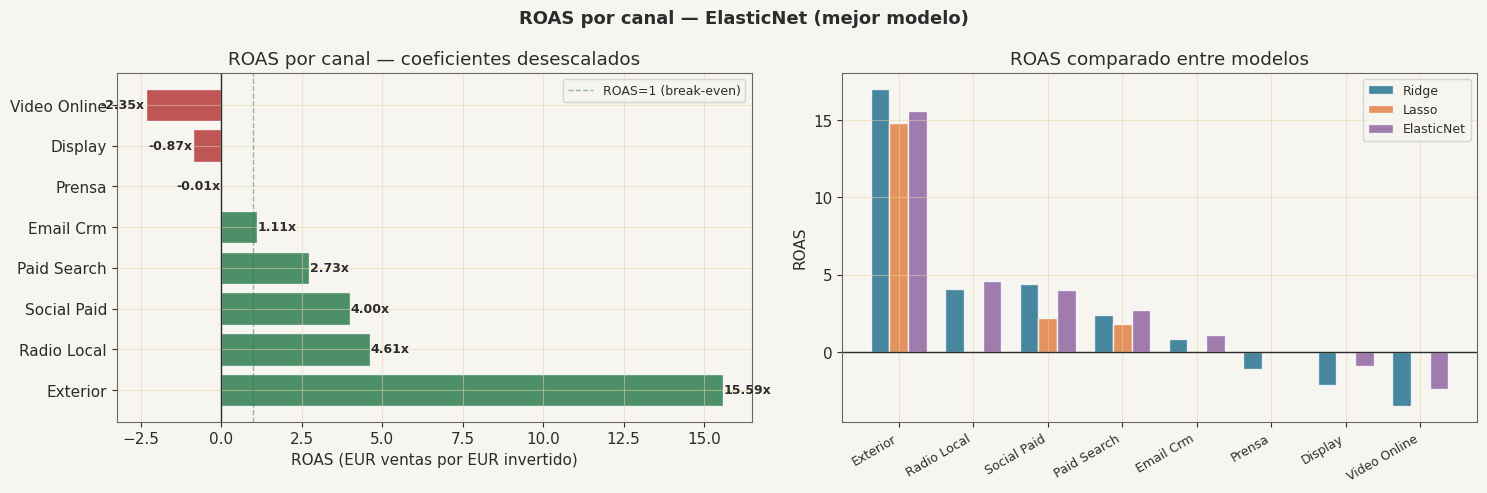

In [35]:
# Visualización ROAS — mejor modelo
roas_mejor = df_roas[df_roas['Modelo'] == mejor_nombre].sort_values('ROAS', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'ROAS por canal — {mejor_nombre} (mejor modelo)',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

# Barras ROAS
ax = axes[0]
canal_names = roas_mejor['Canal'].str.replace('Adstock ', '').values
roas_vals   = roas_mejor['ROAS'].values
colors_roas = [KM['positive'] if v > 1 else (KM['neutral'] if v > 0 else KM['negative'])
               for v in roas_vals]
bars = ax.barh(canal_names, roas_vals, color=colors_roas, edgecolor='white', alpha=0.85)
ax.axvline(0, color=KM['charcoal'], lw=1)
ax.axvline(1, color=KM['positive'], lw=1, ls='--', alpha=0.5, label='ROAS=1 (break-even)')
for bar, val in zip(bars, roas_vals):
    ax.text(val + (0.02 if val >= 0 else -0.02),
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f}x', va='center', ha='left' if val >= 0 else 'right',
            fontsize=9, fontweight='bold')
ax.set_xlabel('ROAS (EUR ventas por EUR invertido)')
ax.set_title('ROAS por canal — coeficientes desescalados')
ax.legend(fontsize=9)

# Comparativa ROAS entre los 3 modelos
ax2 = axes[1]
canales_ord = roas_mejor['Canal'].str.replace('Adstock ', '').values
x = np.arange(len(canales_ord))
w = 0.25
for i, (nombre, color) in enumerate(model_colors.items()):
    roas_mod = df_roas[df_roas['Modelo'] == nombre].set_index('Canal')
    roas_mod.index = roas_mod.index.str.replace('Adstock ', '')
    vals = [roas_mod.loc[c, 'ROAS'] if c in roas_mod.index else 0 for c in canales_ord]
    ax2.bar(x + i*w - w, vals, w, label=nombre, color=color, alpha=0.8, edgecolor='white')
ax2.axhline(0, color=KM['charcoal'], lw=1)
ax2.set_xticks(x)
ax2.set_xticklabels(canales_ord, rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('ROAS')
ax2.set_title('ROAS comparado entre modelos')
ax2.legend(fontsize=9)

plt.tight_layout()
save_fig('04f_roas')
plt.show()

## 10. Exportación de artefactos

In [36]:
# df_coefs — coeficientes y ROAS por modelo y canal
path_coefs = DATA_OUT / 'df_coefs.parquet'
df_roas.to_parquet(path_coefs, index=False)
print(f'df_coefs.parquet: {df_roas.shape} — {path_coefs.stat().st_size/1024:.1f} KB')

# df_predicciones — Y_real + Y_pred de los 3 modelos
df_pred = pd.DataFrame({'semana_inicio': pd.concat([df_train['semana_inicio'],
                                                     df_test['semana_inicio']]).values,
                         'y_real': np.concatenate([y_train, y_test]),
                         'split':  ['train']*len(y_train) + ['test']*len(y_test)})
for nombre, r in resultados.items():
    df_pred[f'y_pred_{nombre.lower()}'] = np.concatenate([r['y_pred_train'], r['y_pred_test']])

path_pred = DATA_OUT / 'df_predicciones.parquet'
df_pred.to_parquet(path_pred, index=False)
print(f'df_predicciones.parquet: {df_pred.shape} — {path_pred.stat().st_size/1024:.1f} KB')

print()
print('RESUMEN FASE 4')
print('=' * 55)
print(f'Mejor modelo:   {mejor_nombre}')
print(f'MAPE test:      {mejor["mape_test"]:.1f}%')
print(f'R² test:        {mejor["r2_test"]:.4f}')
print(f'Parámetros:     {mejor["best_params"]}')

df_coefs.parquet: (24, 6) — 4.7 KB
df_predicciones.parquet: (262, 6) — 15.5 KB

RESUMEN FASE 4
Mejor modelo:   ElasticNet
MAPE test:      8.0%
R² test:        -0.3855
Parámetros:     {'alpha': np.float64(0.2682695795279725), 'l1_ratio': 0.9}


## 11. Resumen de hallazgos y limitaciones

| Aspecto | Hallazgo | Implicación |
|---|---|---|
| **Distribución 2024** | KS test y t-test indican si 2024 es estructuralmente distinto | Si p < 0.05: métricas test son conservadoras; el modelo se enfrenta a condiciones nuevas |
| **Mejor modelo** | ElasticNet/Ridge según CV temporal | Combina L1+L2 o solo L2 para manejar la multicolinealidad severa |
| **Coeficientes negativos** | Si algún canal sale negativo → falta de señal identificable en datos agregados | No se fuerzan a cero: se documentan como limitación y se pasan al modelo bayesiano |
| **ROAS** | Solo interpretable para betas positivas | Los ROAS negativos señalan canales donde el modelo clásico no recupera atribución fiable |
| **Sin saturación** | Modelo lineal puro en X | La linealidad sobreestima ROAS a niveles altos de inversión; se corrige en Fase 5 con curvas Hill |

**Siguiente fase:** `05_bayesiano_mmm.ipynb` — pymc-marketing con saturación Hill/Michaelis-Menten, estimación de lag y alpha como parámetros latentes, intervalos de credibilidad en ROAS.